In [1]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

In [2]:
def radar_factory(num_vars, frame='circle'):
    """
    Create a radar chart with `num_vars` Axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle', 'polygon'}
        Shape of frame surrounding Axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):

        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


In [19]:
def get_compare_annotator_data():
    data_folder="/nfs/users/nfs_j/jc59/quantumwork/pangenome/out/tangle_20_1.3.60_3_5"
    line_labels = []
    spoke_labels = ["Covered", "Used", "Num. break", "Num. indel", "Num. diff", "Identity"]
    
    data = []
    
    for annotate in ["ga", "km", "mg"]:
        new_data = []
        for solver in ["gurobi", "mqlib"]:
            
            file = f"{data_folder}/{solver}.{annotate}.avg.parsed.txt"
            with open(file, 'r') as f:
                lines = f.readlines()
            for line in lines:
                new_data.append([float(x) for x in line.split(' ')[1:]])
                line_labels.append(f"{solver} {line.split(' ')[0]}")
        
        file = f"{data_folder}/pathfinder.{annotate}.avg.parsed.txt"
        with open(file, 'r') as f:
            lines = f.readlines()
        for line in lines:
            new_data.append([float(x) for x in line.strip().split(' ')])
            line_labels.append("Pathfinder")
            
        new_data = np.array(new_data)
        for i in [0, 1, 5]:
            new_data[:, i] = new_data[:, i] / 100
            
        data.append([annotate, new_data])
    all_data = np.array([d[1] for d in data])
    for i in [2, 3, 4]:
        all_data[:, :, i] = all_data[:, :, i] / all_data[:, :, i].max()
    for i in range(len(data)):
        data[i][1] = all_data[i, :, :]
    return data, spoke_labels, line_labels

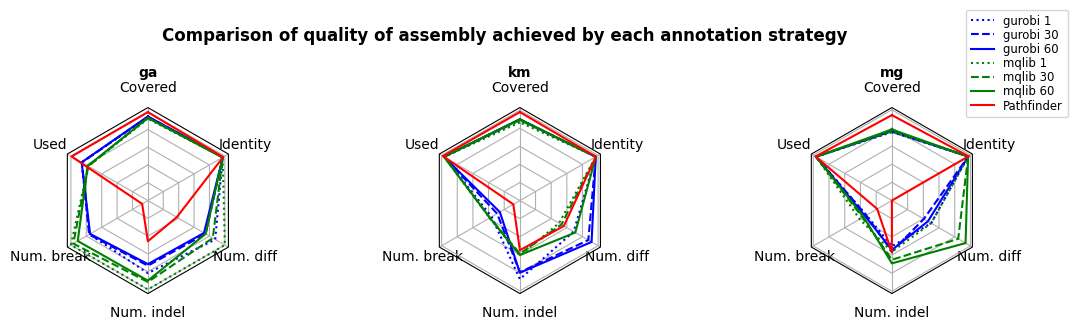

In [20]:
data, spoke_labels, labels = get_compare_annotator_data()

N = data[0][1].shape[1]
theta = radar_factory(N, frame='polygon')

fig, axs = plt.subplots(figsize=(12,20), nrows=1, ncols=3,
                        subplot_kw=dict(projection='radar'))
fig.subplots_adjust(wspace=1, hspace=1, top=0.85, bottom=0.05)

# colors = ['b', 'b', 'b', 'b', 'g', 'g', 'g', 'g', 'r']
# styles = [':', '-.', '--', '-', ':', '-.', '--', '-', '-']
colors = ['b', 'b', 'b', 'g', 'g', 'g', 'r']
styles = [':','--', '-', ':', '--', '-', '-']
for ax, (title, case_data) in zip(axs.flat, data):
    # ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
    ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.1),
                    horizontalalignment='center', verticalalignment='center')
    for i in range(len(case_data)):
        ax.plot(theta, case_data[i], color=colors[i], linestyle=styles[i])  
        # ax.fill(theta, d, alpha=0.25, label='_nolegend_') # , facecolor=color
    ax.set_varlabels(spoke_labels)
    ax.set_yticklabels([])

# add legend relative to top-left plot
legend = axs[2].legend(labels, loc=(0.9, .95),
                            labelspacing=0.1, fontsize='small')



fig.text(0.5, 0.53, 'Comparison of quality of assembly achieved by each annotation strategy',
            horizontalalignment='center', color='black', weight='bold',
            size='large')

plt.show()

In [18]:
def get_compare_solver_data():
    data_folder="/nfs/users/nfs_j/jc59/quantumwork/pangenome/out/tangle_20_1.3.60_3_5"
    line_labels = []
    spoke_labels = ["Covered", "Used", "Num. break", "Num. indel", "Num. diff", "Identity"]
    
    data = []
    
    for solver in ["gurobi", "mqlib", "pathfinder"]:
        new_data = []
        for annotate in ["ga", "km", "mg"]:
            
            file = f"{data_folder}/{solver}.{annotate}.avg.parsed.txt"
            with open(file, 'r') as f:
                lines = f.readlines()
                        
            new_data.append([float(x) for x in lines[-1].split(' ')[1:]])
            line_labels.append(f"{annotate}")
                    
        new_data = np.array(new_data)
        for i in [0, 1, 5]:
            new_data[:, i] = new_data[:, i] / 100
            
        data.append([solver, new_data])
    all_data = np.array([d[1] for d in data])
    for i in [2, 3, 4]:
        all_data[:, :, i] = all_data[:, :, i] / all_data[:, :, i].max()
    for i in range(len(data)):
        data[i][1] = all_data[i, :, :]
    return data, spoke_labels, line_labels

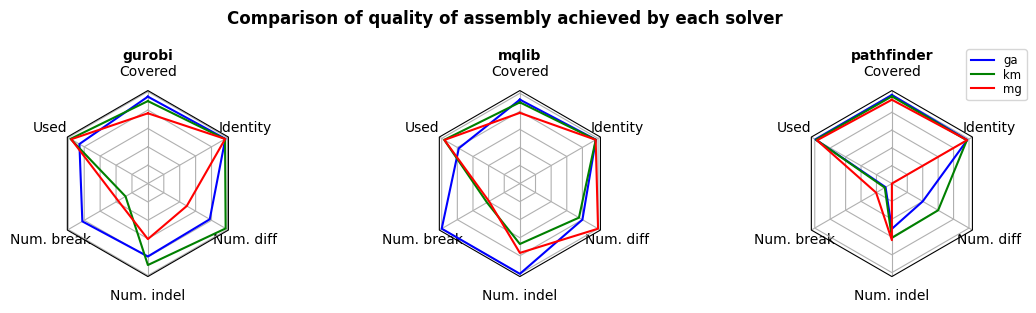

In [16]:
data, spoke_labels, labels = get_compare_solver_data()

N = data[0][1].shape[1]
theta = radar_factory(N, frame='polygon')

fig, axs = plt.subplots(figsize=(12,20), nrows=1, ncols=3,
                        subplot_kw=dict(projection='radar'))
fig.subplots_adjust(wspace=1, hspace=1, top=0.85, bottom=0.05)

colors = ['b', 'g', 'r']
for ax, (title, case_data) in zip(axs.flat, data):
    # ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
    ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.1),
                    horizontalalignment='center', verticalalignment='center')
    for i in range(len(case_data)):
        ax.plot(theta, case_data[i], color=colors[i]) # 
        # ax.fill(theta, d, alpha=0.25, label='_nolegend_') # , facecolor=color
    ax.set_varlabels(spoke_labels)
    ax.set_yticklabels([])
    

# add legend relative to top-left plot
legend = axs[2].legend(labels, loc=(0.9, .95),
                            labelspacing=0.1, fontsize='small')



fig.text(0.5, 0.53, 'Comparison of quality of assembly achieved by each solver',
            horizontalalignment='center', color='black', weight='bold',
            size='large')

plt.show()